In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Rows and columns
df.shape

(200, 5)

In [4]:
# Column names
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [5]:
# Data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
# Statistical summary
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
for column in df.columns:
    print(column, ":", df[column].nunique())

CustomerID : 200
Genre : 2
Age : 51
Annual Income (k$) : 64
Spending Score (1-100) : 84


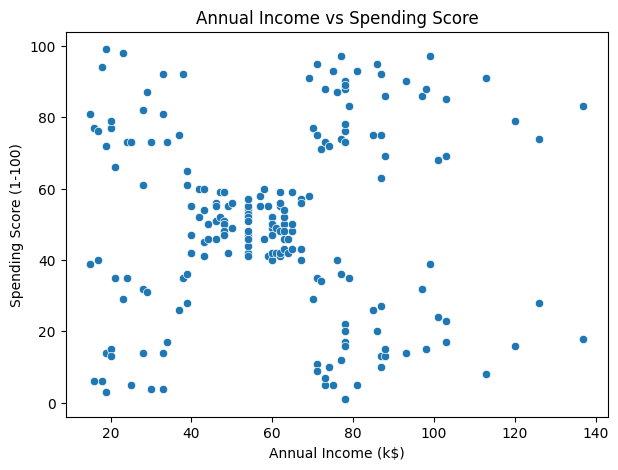

In [10]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)'
)

plt.title('Annual Income vs Spending Score')
plt.show()

In [11]:
X = df[
    ['Annual Income (k$)', 'Spending Score (1-100)']
]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [12]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X)

In [13]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


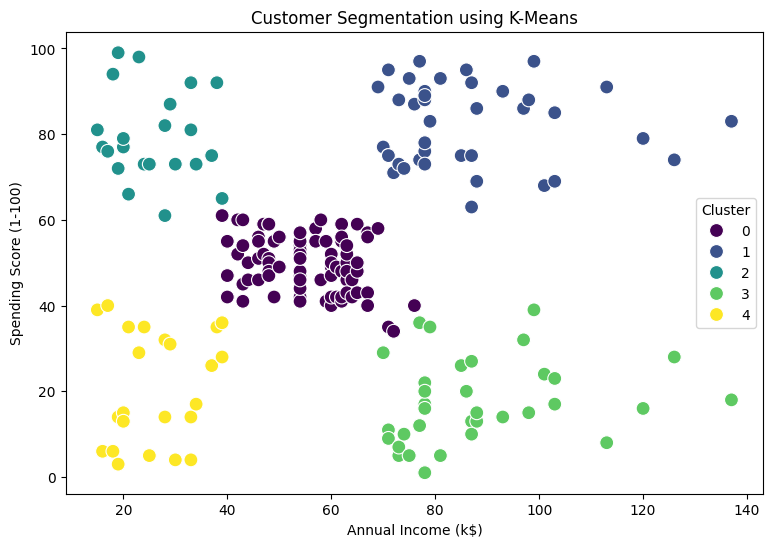

In [14]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='viridis',
    s=100
)

plt.title('Customer Segmentation using K-Means')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.show()

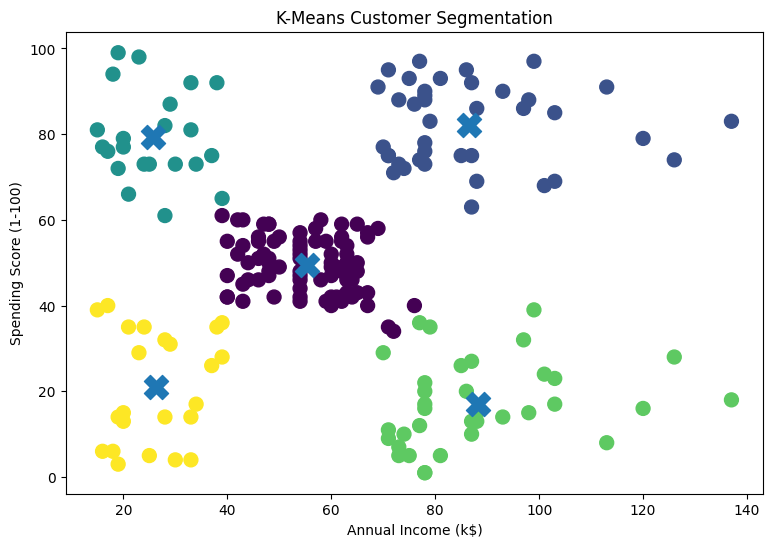

In [15]:
centers = kmeans.cluster_centers_

plt.figure(figsize=(9,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    s=100
)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    s=300,
    marker='X'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Customer Segmentation')

plt.show()

In [16]:
cluster_summary = df.groupby('Cluster').agg({
    'CustomerID': 'count',
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean'
}).round(2)

cluster_summary

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,81,42.72,55.30,49.52
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
3,35,41.11,88.20,17.11
4,23,45.22,26.30,20.91


In [17]:
cluster_summary.rename(
    columns={'CustomerID': 'Number of Customers'},
    inplace=True
)

cluster_summary

,Number of Customers,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,81,42.72,55.30,49.52
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
3,35,41.11,88.20,17.11
4,23,45.22,26.30,20.91


In [18]:
df.to_csv(
    'customer_segments.csv',
    index=False
)